找到 561 张图片，开始处理...
已处理 100 张图片
已处理 200 张图片
已处理 300 张图片
已处理 400 张图片
已处理 500 张图片
已处理 600 张图片
已处理 700 张图片
已处理 800 张图片
已处理 900 张图片
已处理 1000 张图片
已处理 1100 张图片
已处理 1200 张图片
已处理 1300 张图片
已处理 1400 张图片
已处理 1500 张图片
已处理 1600 张图片
已处理 1700 张图片
已处理 1800 张图片
已处理 1900 张图片
已处理 2000 张图片
已处理 2100 张图片
已处理 2200 张图片
已处理 2300 张图片
已处理 2400 张图片
已处理 2500 张图片
已处理 2600 张图片
已处理 2700 张图片
已处理 2800 张图片
已处理 2900 张图片
已处理 3000 张图片
已处理 3100 张图片
已处理 3200 张图片
已处理 3300 张图片
已处理 3400 张图片
已处理 3500 张图片
已处理 3600 张图片
已处理 3700 张图片
已处理 3800 张图片
已处理 3900 张图片
已处理 4000 张图片
已处理 4100 张图片
已处理 4200 张图片
已处理 4300 张图片
已处理 4400 张图片
已处理 4500 张图片
已处理 4600 张图片
已处理 4700 张图片
已处理 4800 张图片
已处理 4900 张图片
已处理 5000 张图片
已处理 5100 张图片
已处理 5200 张图片
已处理 5300 张图片
已处理 5400 张图片
已处理 5500 张图片
已处理 5600 张图片
已处理 5700 张图片
已处理 5800 张图片
已处理 5900 张图片
已处理 6000 张图片
已处理 6100 张图片
已处理 6200 张图片
已处理 6300 张图片
已处理 6400 张图片
已处理 6500 张图片
已处理 6600 张图片
已处理 6700 张图片
已处理 6800 张图片
已处理 6900 张图片
已处理 7000 张图片
已处理 7100 张图片
已处理 7200 张图片
已处理 7300 张图片
已处理 7400 张图片
已处理 7500 张图片
已处理 7600 张图片
已处

C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAPH-5904}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35278\AppData\Local\Temp\ipykernel_28008\2680717123.py:150: UserWarning: Glyph 29

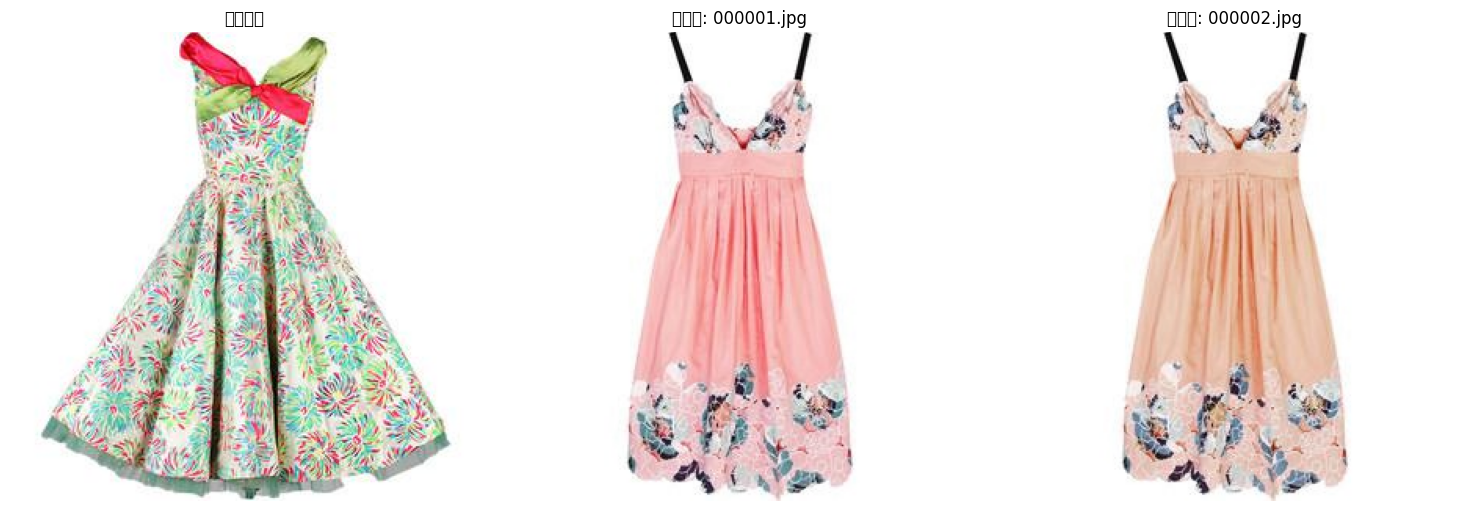

In [1]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import re  # 用于提取文件名中的数字


# 实现论文中描述的色调偏移算法
def hue_shift_with_luminance_preservation(image, shift_value):
    """
    保持亮度的色调偏移算法
    步骤:
    1. RGB -> LAB 并保存L通道
    2. RGB -> HSV
    3. 应用色调偏移
    4. HSV -> RGB -> LAB
    5. 使用原始L通道和新的A、B通道创建新的LAB图像
    6. LAB -> RGB 作为结果
    """
    # 将BGR转换为RGB (因为OpenCV默认读取为BGR)
    rgb_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 转换到LAB色彩空间并保存L通道
    lab_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB)
    l_channel = lab_img[:, :, 0].copy()  # 缓存原始亮度通道

    # 转换到HSV色彩空间
    hsv_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)

    # 应用色调偏移 (OpenCV的HSV中H通道范围是0-179而非0-360)
    h_channel = hsv_img[:, :, 0].copy()
    shift_value_opencv = shift_value % 360 / 2  # 转换为OpenCV的H范围
    h_channel = (h_channel + shift_value_opencv).astype(np.uint8)

    # 创建新的HSV图像
    hsv_shifted = hsv_img.copy()
    hsv_shifted[:, :, 0] = h_channel

    # 将偏移后的HSV转换回RGB，再转换为LAB
    rgb_shifted = cv2.cvtColor(hsv_shifted, cv2.COLOR_HSV2RGB)
    lab_shifted = cv2.cvtColor(rgb_shifted, cv2.COLOR_RGB2LAB)

    # 使用原始L通道和新的A、B通道
    lab_final = lab_shifted.copy()
    lab_final[:, :, 0] = l_channel  # 恢复原始亮度

    # 转换回RGB
    result = cv2.cvtColor(lab_final, cv2.COLOR_LAB2RGB)

    # 转换回BGR用于保存
    return cv2.cvtColor(result, cv2.COLOR_RGB2BGR)

# 处理文件夹中的所有图片
def process_images(input_dir, output_dir, num_shifts=18, step=20):
    # 检查输出文件夹是否存在
    if not os.path.exists(output_dir):
        raise ValueError(f"输出文件夹不存在: {output_dir}，请确认路径是否正确")

    # 获取输入文件夹中的所有图片
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.gif']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob(os.path.join(input_dir, ext)))

    if not image_paths:
        print(f"在输入文件夹 {input_dir} 中未找到任何图片")
        return

    # 按文件名中的数字对图片路径进行排序（解决2.jpg在10.jpg之后的问题）
    image_paths.sort(key=lambda x: extract_number(os.path.basename(x)))

    print(f"找到 {len(image_paths)} 张图片，开始处理...")

    # 初始化计数器用于命名
    counter = 1

    # 对每张图片应用多次色调偏移
    for img_path in image_paths:
        # 读取图片
        img = cv2.imread(img_path)
        if img is None:
            print(f"无法读取图片: {img_path}")
            continue

        # 应用多次色调偏移（18次，步长20）
        for i in range(num_shifts):
            shift_value = i * step
            shifted_img = hue_shift_with_luminance_preservation(img, shift_value)

            # 生成文件名（6位数字）
            filename = f"{counter:06d}.jpg"
            output_path = os.path.join(output_dir, filename)

            # 保存图片
            cv2.imwrite(output_path, shifted_img)

            # 每处理100张图片打印一次进度
            if counter % 100 == 0:
                print(f"已处理 {counter} 张图片")

            counter += 1

    print(f"处理完成，共生成 {counter - 1} 张图片")

def extract_number(filename):
    """从文件名中提取数字（用于排序）"""
    numbers = re.findall(r'\d+', filename)  # 提取所有数字部分（如"123"）
    if numbers:
        return int(numbers[0])  # 返回第一个数字的整数值（适应"1.jpg"、"10.png"等格式）
    return 0  # 若文件名无数字，按0排序（可根据实际情况调整）


# 示例：使用代码
if __name__ == "__main__":
    # 设置输入和输出文件夹路径（请修改为您的实际路径）
    input_directory = "Re-TypeAware(1)/dress"    # 存放原始图片的文件夹
    output_directory = "Re-TypeAware(1)/dress/hue_shift_augmentation"  # 您已有的输出文件夹

    # 处理图片
    process_images(input_directory, output_directory)

    # 显示示例结果（可选）
    def show_example():
        # 检查是否有处理后的图片
        output_images = glob(os.path.join(output_directory, "*.jpg"))
        if output_images and len(output_images) >= 3:
            plt.figure(figsize=(15, 5))

            # 原始图片
            original_path = glob(os.path.join(input_directory, "*.*"))[0]
            original_img = cv2.imread(original_path)
            original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

            plt.subplot(131)
            plt.imshow(original_img_rgb)
            plt.title("原始图片")
            plt.axis("off")

            # 显示两张处理后的图片
            for i, img_path in enumerate(output_images[:2]):
                img = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                plt.subplot(132 + i)
                plt.imshow(img_rgb)
                plt.title(f"处理后: {os.path.basename(img_path)}")
                plt.axis("off")

            plt.tight_layout()
            plt.show()

    # 显示示例（取消注释即可运行）
    show_example()
